## Exercício

Considere $X \sim \mathrm{Binomial}(n,p)$.

1. Implemente a simulação de $X$ pelo método ingênuo, escrevendo $X$ como soma de $n$ variáveis aleatórias independentes com distribuição $\mathrm{Bernoulli}(p)$.

2. Implemente o método recursivo visto em sala:

   * Gere $U \sim U(0,1)$.

   * Inicialize $i=0$, $p_i=(1-p)^n$ e $F=p_i$.

   * Enquanto $U>F$, faça

     $$
     p_{i+1}=
     \frac{n-i}{i+1}
     \frac{p}{1-p}
     p_i,
     $$

     e atualize $i \leftarrow i+1$ e $F \leftarrow F+p_i$.

   * Retorne $X=i$.

3. Use a função `np.linspace` para reproduzir os passos anteriores para diferentes valores de $p$, compare o tempo de execução dos dois métodos. Para cada valor de $p$, execute cada método 100 vezes e calcule a média dos tempos. Utilize `time.time()` para medir o tempo de execução de cada método.

4. Apresente os resultados em uma tabela ou gráfico e comente como o tempo de execução dos métodos varia com $p$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

In [ ]:
#Parte 1
n = 1000
p = .5
N = 10
amostra = []

for i in range(N):
  uniforme = np.random.uniform(size = n)
  amostra.append(np.sum(uniforme<p))

amostra

[np.int64(505),
 np.int64(489),
 np.int64(488),
 np.int64(488),
 np.int64(535),
 np.int64(488),
 np.int64(517),
 np.int64(489),
 np.int64(527),
 np.int64(487)]

(array([   7.,   82.,  570., 1187., 2841., 2996., 1423.,  728.,  144.,
          22.]),
 array([21. , 24.7, 28.4, 32.1, 35.8, 39.5, 43.2, 46.9, 50.6, 54.3, 58. ]),
 <BarContainer object of 10 artists>)

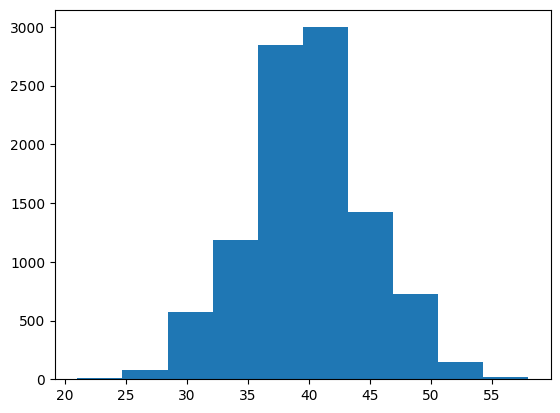

In [ ]:
#Parte 2
p = 0.4
n = 100
N = 10000
amostra = []
for j in range(N):
  i = 0
  pi = (1-p)**n
  F = pi
  U = np.random.uniform(0,1, size = 1)
  while U>F:
    pi = (((n-i)/(i+1))*(p/(1-p)))*pi
    i = i+1
    F = F+pi
  amostra.append(i)
plt.hist(amostra)

In [ ]:
p_valores = np.linspace(0.1,0.99,15)
tempo_ingenuo = []
tempo_recursivo = []

for p in p_valores:
  tempo_rec = []
  tempo_ing = []

  for loop in tqdm(range(100)):
    inicio = time.time()
    n = 100
    N = 1000
    amostra = []

    for i in range(N):
      uniforme = np.random.uniform(size = n)
      amostra.append(np.sum(uniforme<p))
    fim = time.time()

    tempo = fim-inicio
    tempo_ing.append(tempo)


    inicio_rec = time.time()
    n = 100
    N = 1000
    amostra_recursiva = []
    for j in range(N):
      i = 0
      pi = (1-p)**n
      F = pi
      U = np.random.uniform(0,1, size = 1)
      while U>F:
        pi = (((n-i)/(i+1))*(p/(1-p)))*pi
        i = i+1
        F = F+pi
      amostra_recursiva.append(i)

    fim_rec = time.time()
    tempo_dif = fim_rec - inicio_rec
    tempo_rec.append(tempo_dif)

  tempo_ingenuo.append(np.mean(tempo_ing))
  tempo_recursivo.append(np.mean(tempo_rec))


100%|██████████| 100/100 [00:28<00:00,  3.52it/s]


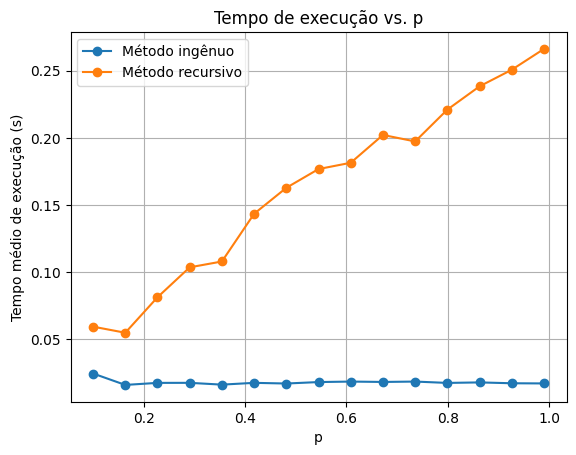

In [ ]:
import matplotlib.pyplot as plt

plt.plot(p_valores, tempo_ingenuo, marker='o', label='Método ingênuo')
plt.plot(p_valores, tempo_recursivo, marker='o', label='Método recursivo')
plt.xlabel('p')
plt.ylabel('Tempo médio de execução (s)')
plt.title('Tempo de execução vs. p')
plt.legend()
plt.grid(True)
plt.show()

Com o aumento do valor de p, o método ingênuo não sofre variações no tempo de execução, já o método recursivo sofre um grande aumento no seu tempo de execução